In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설정된 폰트 목록 출력
sys_font = [f.name for f in fm.fontManager.ttflist]
print(sys_font)

# 나눔고딕 폰트가 목록에 있는지 확인
print('NanumGothic' in sys_font)

['DejaVu Sans Display', 'STIXSizeThreeSym', 'DejaVu Sans Mono', 'STIXGeneral', 'STIXGeneral', 'STIXSizeOneSym', 'cmmi10', 'DejaVu Sans', 'STIXNonUnicode', 'cmtt10', 'STIXSizeOneSym', 'DejaVu Sans', 'DejaVu Serif', 'DejaVu Sans Mono', 'STIXNonUnicode', 'DejaVu Sans', 'cmss10', 'cmr10', 'cmsy10', 'STIXSizeFiveSym', 'STIXGeneral', 'STIXSizeThreeSym', 'DejaVu Serif', 'STIXSizeFourSym', 'DejaVu Serif Display', 'STIXSizeTwoSym', 'STIXGeneral', 'STIXSizeTwoSym', 'STIXSizeFourSym', 'DejaVu Sans Mono', 'cmb10', 'cmex10', 'DejaVu Sans Mono', 'DejaVu Sans', 'DejaVu Serif', 'STIXNonUnicode', 'STIXNonUnicode', 'DejaVu Serif', 'Liberation Sans', 'Liberation Serif', 'Liberation Serif', 'NanumSquare', 'Liberation Sans', 'NanumSquareRound', 'Liberation Sans Narrow', 'Liberation Sans Narrow', 'NanumBarunGothic', 'NanumBarunGothic', 'Liberation Sans Narrow', 'NanumSquare', 'Humor Sans', 'Liberation Mono', 'Liberation Sans Narrow', 'NanumMyeongjo', 'NanumSquareRound', 'NanumGothicCoding', 'NanumGothicCodi

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import koreanize_matplotlib

# 한국어 형태소 분석 및 데이터 시각화

이 노트북은 Bareun API를 사용하여 한국어 텍스트 데이터에서 명사를 추출하고, 다양한 시각화 기법을 통해 분석하는 방법을 설명합니다.

## 주요 기능
1. Bareun API를 사용한 한국어 형태소 분석
2. 뉴스 데이터에서 명사 추출
3. 워드클라우드, 네트워크 분석, 막대 차트를 통한 시각화

In [ ]:
# Bareun API 패키지 다운로드
# curl 명령을 사용해 Bareun Linux 패키지를 다운로드
# -L: 리다이렉션을 따름, -J: Content-Disposition 헤더 존재 시 파일명 사용, -k: SSL 인증 검증 무시, -s: 진행 상황 표시 없음
!curl -LJks -H "uname:$(uname -a)" https://bareun.ai/api/get -o bareun-linux.deb

# 현재 디렉토리의 파일 목록 표시
!ls

bareun-linux.deb  nohup.out  sample_data


In [ ]:
# 시스템 정보 출력
# uname -a: 운영체제 이름, 호스트명, 커널 버전 등의 시스템 정보 출력
!uname -a

Linux 952c7bc20a0d 6.1.123+ #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux


In [ ]:
# 다운로드한 Bareun 패키지 설치
# dpkg -i: 데비안 패키지 설치
!dpkg -i bareun-linux.deb

(Reading database ... 126542 files and directories currently installed.)
Preparing to unpack bareun-linux.deb ...
System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to connect to bus: Host is down
System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to connect to bus: Host is down
Configuration file /etc/systemd/system/bareun.service is marked executable. Please remove executable permission bits. Proceeding anyway.
Removed /etc/systemd/system/multi-user.target.wants/bareun.service.
Unpacking bareun (3.0.rc3) over (3.0.rc3) ...
Setting up bareun (3.0.rc3) ...
System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to connect to bus: Host is down
System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to connect to bus: Host is down
Configuration file /etc/systemd/system/bareun.service is marked executable. Please remove executable permission bits. Proceeding an

In [ ]:
# Bareun 환경 변수 설정
# %env: Jupyter 매직 명령어로 환경 변수 설정
%env BAREUN_ROOT="/opt/bareun"  # Bareun 설치 루트 경로 설정
%env LD_LIBRARY_PATH="/opt/bareun/lib"  # 라이브러리 경로 설정

# Bareun 서비스 백그라운드로 실행
# nohup: 로그아웃 후에도 명령이 계속 실행되도록 함
# &: 명령을 백그라운드로 실행
!BAREUN_ROOT="/opt/bareun" LD_LIBRARY_PATH="/opt/bareun/lib" nohup /opt/bareun/bin/bareun&

env: BAREUN_ROOT="/opt/bareun"  # Bareun 설치 루트 경로 설정
env: LD_LIBRARY_PATH="/opt/bareun/lib"  # 라이브러리 경로 설정
nohup: appending output to 'nohup.out'


In [ ]:
# Bareun 프로세스 실행 확인
# ps -ef: 모든 프로세스 상세 정보 출력
# grep bareun: bareun 문자열이 포함된 라인만 필터링
!ps -ef | grep bareun

root       18612       1  1 10:45 ?        00:00:16 /opt/bareun/bin/bareun
root       22485       1  0 11:01 ?        00:00:00 /opt/bareun/bin/bareun
root       22486   21882  0 11:01 ?        00:00:00 /bin/bash -c ps -ef | grep bareun
root       22488   22486  0 11:01 ?        00:00:00 grep bareun


In [ ]:
# API 키 등록
# -reg 옵션: API 키 등록
!BAREUN_ROOT="/opt/bareun" LD_LIBRARY_PATH="/opt/bareun/lib" /opt/bareun/bin/bareun -reg koba-SDMPUPQ-LKGE25Y-V6UEL5A-NRDZSOY

2025-07-20 11:22:10.071161: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/bareun/lib
2025-07-20 11:22:10.071292: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
Use config file: /opt/bareun/config/bareun.json

------
200 OK
sucessfully registered koba-SDMPUPQ-LKGE25Y-V6UEL5A-NRDZSOY


In [ ]:
# Bareun Python 패키지(bareunpy) 설치 또는 업데이트
# -U: 이미 설치된 패키지를 최신 버전으로 업그레이드
!pip install -U bareunpy

## 1단계: Bareun API 초기화

이제 Bareun API를 사용하기 위해 필요한 라이브러리를 임포트하고 API를 초기화합니다.

### 주요 컴포넌트:
- **Tagger**: 형태소 분석을 수행하는 객체
- **Tokenizer**: 토크나이징을 수행하는 객체
- **API_KEY**: Bareun API 사용을 위한 인증 키

In [ ]:
# 필요한 라이브러리 임포트
import sys  # 시스템 관련 함수 및 변수 제공
import google.protobuf.text_format as tf  # 프로토콜 버퍼 텍스트 포맷 처리
from bareunpy import Tagger  # 형태소 분석기
from bareunpy import Tokenizer  # 토크나이저
from collections import defaultdict  # 기본값이 있는 딕셔너리

# Bareun API 초기화
API_KEY="koba-SDMPUPQ-LKGE25Y-V6UEL5A-NRDZSOY"  # API 키 설정
tagger = Tagger(API_KEY, 'localhost', 5656)  # 형태소 분석기 객체 생성 (localhost:5656 서버에 연결)
tokenizer = Tokenizer(API_KEY, 'localhost', 5656)  # 토크나이저 객체 생성

In [ ]:
# 연습: 위의 코드를 따라서 타이핑해보세요


## 2단계: 데이터 불러오기

분석할 뉴스 데이터를 Excel 파일에서 불러옵니다.

### 주요 포인트:
- pandas를 사용하여 Excel 파일을 DataFrame으로 로드
- 데이터의 구조와 내용을 확인
- 컬럼명과 데이터 타입 파악

In [ ]:
# pandas 라이브러리 임포트 (데이터 처리)
import pandas as pd

# Excel 파일 불러오기
file_path = '/content/교권_news.xlsx'  # 분석할 Excel 파일 경로

# DataFrame으로 Excel 파일 로드
# sheet_name=0: 첫 번째 시트 선택
df = pd.read_excel(file_path, sheet_name=0)

# 데이터 미리보기 출력
print("Excel file loaded successfully. Preview:")  # 성공 메시지
print(df.head())  # 처음 5개 행 출력

# 데이터프레임 기본 정보 출력
print("\nDataFrame info:")
print(f"Shape: {df.shape}")  # 행과 열의 수 (shape)
print(f"Columns: {df.columns.tolist()}")  # 컬럼명 목록

Excel file loaded successfully. Preview:
                                         제목  \
0                     [채희창칼럼] 날개 없이 추락하는 교권   
1  이재명 후보 '미래교육자치위원회' 공식 출범… 200명 넘는 전문가 집결   
2                        [교육논단] 교육 공약을 살펴보다   
3       [앵커 브리핑] 갈수록 추락하는 교권···공교육 회복은 어떻게?   
4                       비참한 교권, 누가 이렇게 만들었나   

                                                  본문  
0  늘어 교권 보호 없인 국가 발전 어려워 지난달 28일 부산의 한 초등학교에서 5학년...  
1  총장), 교권보호특위(김성근 전 교육부 학교혁신지원실장), 학부모소통특위(김유임 전...  
2  각종 제도와 장치를 통해서 교권과 학습권을 강화하여 교육 회복을 여는 것. 기초 학...  
3  2023년 서이초 사건 당시 전국의 교사들이 거리로 나와 ‘공교육 멈춤의 날’ 집회...  
4  교권은 오랫동안 학생과 학부모, 그리고 그 잘난 정치인들에게 셀 수도 없을 만큼 차...  

DataFrame info:
Shape: (100, 2)
Columns: ['제목', '본문']


In [ ]:
# 연습: 데이터 불러오기 코드를 작성해보세요


## 3단계: 명사 추출 및 빈도 분석

이제 본격적으로 형태소 분석을 수행합니다.

### 작업 과정:
1. 제목과 본문에서 명사만 추출하는 함수 정의
2. 한 글자 명사는 제외 (의미가 모호하기 때문)
3. 모든 명사의 빈도수를 계산
4. 상위 20개 명사 추출

### 형태소 분석의 이해:
- 형태소: 의미를 가진 언어의 최소 단위
- 명사 추출: 텍스트의 핵심 키워드를 파악하는 데 유용
- 빈도 분석: 어떤 주제가 가장 많이 언급되는지 파악

In [ ]:
# 제목/본문에서 명사 추출 함수 (한 글자 명사 제외)
def extract_nouns_from_texts(texts, tagger):
    all_nouns = []
    for text in texts:
        if not isinstance(text, str):
            continue
        nouns = tagger.tags([text]).nouns()
        nouns = [noun for noun in nouns if len(noun) > 1]  # 한 글자 명사 제외
        all_nouns.extend(nouns)
    return all_nouns

In [ ]:
# 연습: 명사 추출 함수를 작성해보세요


In [ ]:
# 제목에서 명사 추출
title_texts = df['제목'].dropna().tolist()
title_nouns = extract_nouns_from_texts(title_texts, tagger)

# 본문에서 명사 추출
content_texts = df['본문'].dropna().tolist()
content_nouns = extract_nouns_from_texts(content_texts, tagger)

# 제목+본문 전체 명사 합치기
all_nouns = title_nouns + content_nouns

# 빈도수 집계
from collections import Counter
noun_counts = Counter(all_nouns)
top_nouns = noun_counts.most_common(20)

print("상위 20개 명사와 빈도:")
for noun, count in top_nouns:
    print(f"{noun}: {count}")

상위 20개 명사와 빈도:
교권: 178
교육: 134
보호: 77
교사: 76
학생: 42
후보: 41
침해: 41
학교: 29
교원: 28
활동: 28
강화: 26
공약: 25
스승: 25
위원회: 19
학부모: 19
현장: 18
이재명: 17
대선: 17
..: 16
지원: 16


In [ ]:
# 연습: 명사 추출 및 빈도 계산 코드를 작성해보세요


## 4단계: 워드클라우드 시각화

추출된 명사들을 워드클라우드로 시각화합니다.

### 워드클라우드란?
- 텍스트 데이터에서 중요한 단어들을 시각적으로 표현
- 단어의 빈도에 따라 글자 크기가 결정됨
- 직관적으로 주요 키워드를 파악할 수 있음

### 한글 처리 주의사항:
- 한글 폰트 지정 필수 (NanumGothic.ttf)
- 폰트 경로를 정확히 설정해야 함

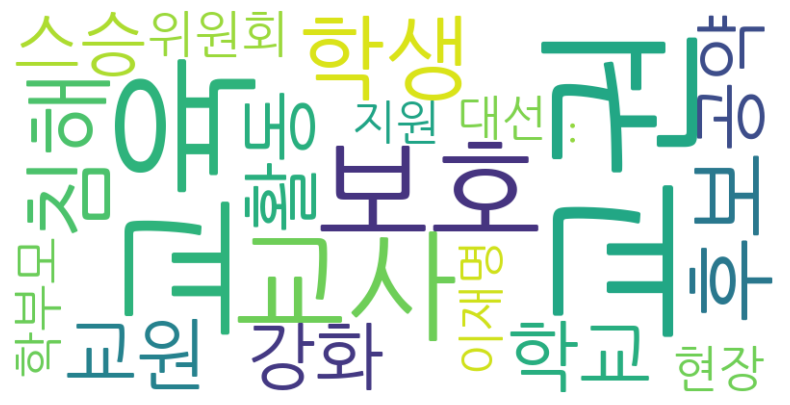

In [ ]:
# 워드클라우드 시각화

from wordcloud import WordCloud  # 워드클라우드 생성을 위한 라이브러리 임포트
import matplotlib.pyplot as plt  # 그래프(이미지) 출력을 위한 라이브러리 임포트

# 워드클라우드 객체 생성
# - font_path: 한글 폰트 경로 지정 (한글 깨짐 방지)
# - width, height: 워드클라우드 이미지 크기 지정
# - background_color: 배경색 지정
wordcloud = WordCloud(font_path='NanumGothic.ttf', width=800, height=400, background_color='white')

# top_nouns(상위 20개 명사와 빈도) 정보를 워드클라우드에 적용
# dict(top_nouns): [('단어', 빈도), ...] 형태를 딕셔너리로 변환
wordcloud.generate_from_frequencies(dict(top_nouns))

# 워드클라우드 이미지를 그릴 도화지(figure) 생성, 크기 지정
plt.figure(figsize=(10, 5))

# 워드클라우드 이미지를 화면에 표시
# interpolation='bilinear'는 이미지를 부드럽게 보이게 함
plt.imshow(wordcloud, interpolation='bilinear')

# x, y축 눈금(테두리) 숨기기
plt.axis('off')

# 실제로 이미지를 화면에 출력
plt.show()

In [ ]:
# 연습: 워드클라우드 생성 코드를 작성해보세요


## 5단계: 막대그래프 시각화

명사 빈도를 막대그래프로 시각화합니다.

### 막대그래프의 장점:
- 정확한 수치 비교가 가능
- 순위를 명확하게 파악할 수 있음
- 워드클라우드보다 정량적 분석에 유리

### 시각화 팁:
- x축 라벨을 45도 회전하여 가독성 향상
- 적절한 그래프 크기 설정으로 보기 좋게 구성

In [ ]:
# 막대그래프 시각화
import matplotlib.pyplot as plt  # 그래프를 그리기 위한 라이브러리 임포트

# top_nouns는 [('단어', 빈도), ...] 형태의 리스트임
# zip(*top_nouns)를 사용하면 단어와 빈도수를 각각 분리해서 labels, values에 저장
labels, values = zip(*top_nouns)

# 그래프의 크기를 가로 10, 세로 5로 설정
plt.figure(figsize=(10, 5))

# 막대그래프(bar chart) 그리기: labels(단어)가 x축, values(빈도수)가 y축
plt.bar(labels, values)

# x축의 단어들이 겹치지 않도록 45도 기울여서 표시
plt.xticks(rotation=45)

# 그래프의 제목 설정
plt.title('상위 20개 명사 빈도')

# 그래프를 화면에 출력
plt.show()

In [ ]:
# 연습: 막대그래프 생성 코드를 작성해보세요


## 6단계: 네트워크 분석 (고급)

명사들 간의 관계를 네트워크 그래프로 시각화합니다.

### 네트워크 분석이란?
- 같은 문서에 함께 등장하는 단어들을 연결하여 시각화
- 단어들 간의 관계성과 연관성을 파악
- 주제의 구조와 연결고리를 이해하는 데 유용

### 분석 과정:
1. 각 문서별로 명사 리스트 생성
2. 상위 빈도 명사만 선별
3. 동시 출현 빈도 계산
4. 네트워크 그래프로 시각화

### 주요 매개변수:
- **co-occurrence threshold**: 함께 등장하는 최소 횟수 (여기서는 2회)
- **spring layout**: 노드들의 위치를 자동으로 최적화

In [ ]:
import matplotlib.pyplot as plt  # 그래프(시각화)를 그리기 위한 라이브러리
import networkx as nx            # 네트워크 그래프를 그리기 위한 라이브러리
from collections import Counter, defaultdict  # 데이터 집계와 기본값 딕셔너리 사용

### 단계 1: 각 문서별로 명사 리스트 만들기

네트워크 분석을 위해서는 먼저 각 문서(뉴스 기사)별로 명사들을 추출해야 합니다.
- 제목과 본문에서 각각 명사를 추출
- 한 글자 명사는 제외 (의미가 불분명하므로)
- 각 문서의 명사들을 리스트로 저장

In [ ]:
# 1. 각 문서별로 명사 리스트 만들기
doc_nouns = []  # 각 문서의 명사 리스트를 저장할 빈 리스트 생성
for idx, row in df.iterrows():  # 데이터프레임의 각 행(문서)에 대해 반복
    title = row['제목']         # 제목 컬럼에서 텍스트 추출
    content = row['본문']       # 본문 컬럼에서 텍스트 추출
    nouns = []                  # 한 문서의 명사들을 저장할 리스트
    if isinstance(title, str):  # 제목이 문자열이면
        # 제목에서 명사만 추출(길이 2 이상만), 리스트에 추가
        nouns += [n for n in tagger.tags([title]).nouns() if len(n) > 1]
    if isinstance(content, str):  # 본문이 문자열이면
        # 본문에서 명사만 추출(길이 2 이상만), 리스트에 추가
        nouns += [n for n in tagger.tags([content]).nouns() if len(n) > 1]
    doc_nouns.append(nouns)      # 한 문서의 명사 리스트를 전체 리스트에 추가

### 단계 2: 상위 빈도 명사 선별

네트워크가 너무 복잡해지지 않도록 가장 많이 등장하는 상위 20개 명사만 선별합니다.
- 전체 명사를 하나의 리스트로 합치기
- Counter를 사용해 빈도 계산
- 상위 20개만 선택

In [ ]:
# 2. 전체 문서에서 상위 20개 명사만 추출
all_nouns = [n for nouns in doc_nouns for n in nouns]  # 모든 문서의 명사를 하나의 리스트로 합침
top_nouns = set([n for n, _ in Counter(all_nouns).most_common(20)])  # 가장 많이 나온 20개 명사만 set으로 저장

### 단계 3: 명사 동시 출현 분석

같은 문서에 함께 등장하는 명사들을 찾아 동시 출현 횟수를 계산합니다.
- 각 문서에서 상위 20개 명사만 필터링
- 모든 명사 쌍의 조합을 만들어 동시 출현 횟수 카운트
- defaultdict를 사용해 효율적으로 집계

In [ ]:
# 3. 명사들의 동시 출현(같은 문서에 함께 등장) 횟수 세기
co_occur = defaultdict(int)  # (명사1, 명사2) 쌍의 동시 출현 횟수를 저장할 딕셔너리
for nouns in doc_nouns:      # 각 문서의 명사 리스트에 대해
    filtered = [n for n in nouns if n in top_nouns]  # 상위 20개 명사만 남김
    for i in range(len(filtered)):                   # 명사 리스트에서
        for j in range(i+1, len(filtered)):          # 모든 명사 쌍에 대해
            pair = tuple(sorted([filtered[i], filtered[j]]))  # 명사 쌍을 알파벳순으로 정렬하여 튜플로 만듦
            co_occur[pair] += 1                      # 해당 쌍이 함께 등장한 횟수 1 증가

### 단계 4: 네트워크 그래프 생성

NetworkX 라이브러리를 사용해 명사들 간의 관계를 네트워크로 시각화합니다.
- 2번 이상 함께 등장한 명사 쌍만 연결
- 노드는 명사, 간선은 동시 출현 관계를 나타냄
- 간선의 가중치는 동시 출현 횟수

In [ ]:
# 4. 네트워크 그래프 생성 및 시각화
G = nx.Graph()  # 빈 그래프 객체 생성
for (a, b), cnt in co_occur.items():  # 동시 출현 쌍과 등장 횟수에 대해 반복
    if cnt >= 2:                      # 2번 이상 함께 등장한 쌍만 그래프에 추가
        G.add_edge(a, b, weight=cnt)  # 명사 a, b를 연결하는 간선 추가(가중치는 등장 횟수)

### 단계 5: 네트워크 시각화

생성된 네트워크 그래프를 matplotlib을 사용해 시각화합니다.
- spring_layout: 노드들이 자연스럽게 배치되도록 하는 레이아웃
- 노드 크기, 색상, 폰트 등을 조정하여 가독성 향상
- 한글 폰트 지정으로 명사가 제대로 표시되도록 설정

In [ ]:
plt.figure(figsize=(10, 6))           # 그래프 크기 설정
pos = nx.spring_layout(G, seed=42)    # 노드의 위치를 spring layout으로 자동 배치(랜덤시드 고정)
nx.draw(
    G, pos, with_labels=True,         # 노드에 라벨(명사) 표시
    node_size=4800,                   # 노드 크기
    node_color='skyblue',             # 노드 색상
    font_size=15,                     # 글씨 크기
    font_family='NanumGothic'         # 한글 폰트 지정(한글 깨짐 방지)
)
plt.title('단어 네트워크(상위 20개 명사)')  # 그래프 제목
plt.show()                              # 그래프 화면에 출력

## 네트워크 분석 결과 해석

생성된 네트워크 그래프를 통해 다음과 같은 정보를 얻을 수 있습니다:

### 1. 중심 단어 파악
- **연결이 많은 노드**: 다른 많은 단어들과 함께 등장하는 핵심 키워드
- **크기가 큰 노드**: 문서에서 자주 언급되는 중요한 개념

### 2. 단어 클러스터 분석
- **밀집된 그룹**: 관련성이 높은 단어들의 클러스터
- **연결 패턴**: 주제별로 묶이는 단어들의 관계

### 3. 맥락 이해
- **간선의 굵기**: 동시 출현 빈도가 높을수록 굵게 표시 (현재 코드에서는 동일하게 표시)
- **거리**: 관련성이 높은 단어들은 가까이 배치됨

### 네트워크 분석의 활용
- **주제 모델링**: 관련 단어들의 그룹핑을 통한 주제 발견
- **키워드 추천**: 중심성이 높은 단어들을 핵심 키워드로 활용
- **문서 분류**: 단어 간 관계 패턴을 이용한 문서 분류

## 전체 실습 요약

이번 실습에서는 Bareun API를 활용하여 한국어 텍스트 데이터를 분석하고 시각화하는 방법을 학습했습니다.

### 주요 학습 내용

1. **환경 설정**
   - Bareun API 설치 및 설정
   - 한글 폰트 설정
   - 필요한 라이브러리 설치

2. **데이터 전처리**
   - Excel 파일 데이터 로드
   - 형태소 분석을 통한 명사 추출
   - 불용어 처리 (한 글자 명사 제거)

3. **텍스트 분석**
   - 빈도 분석을 통한 핵심 키워드 발견
   - 동시 출현 분석을 통한 단어 간 관계 파악

4. **데이터 시각화**
   - **워드클라우드**: 단어의 빈도를 직관적으로 표현
   - **막대 차트**: 상위 키워드의 정확한 빈도 비교
   - **네트워크 그래프**: 단어 간의 관계와 구조 분석

### 실무 활용 방안
- **언론 분석**: 뉴스 기사의 주요 이슈와 키워드 트렌드 파악
- **소셜 미디어 분석**: SNS 게시물의 여론과 관심사 분석
- **고객 피드백 분석**: 리뷰나 설문조사 데이터의 주요 의견 추출
- **학술 연구**: 논문이나 보고서의 핵심 개념과 관계 분석